In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv('/Users/GIO/Documents/Machinelearning/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [4]:
df['region_num'] = pd.factorize(df['region'])[0] + 1

In [5]:
df['region_num']

0       1
1       2
2       2
3       3
4       3
       ..
1333    3
1334    4
1335    2
1336    1
1337    3
Name: region_num, Length: 1338, dtype: int64

In [6]:
df.drop(columns='region',inplace=True)

In [7]:
df['sex'].unique()


array(['female', 'male'], dtype=object)

In [8]:
df['sex'] = (df['sex'] == 'female').astype(int)

In [9]:
df['sex'].unique()


array([1, 0])

In [10]:
df['smoker'] = (df['smoker'] == 'yes').astype(int)

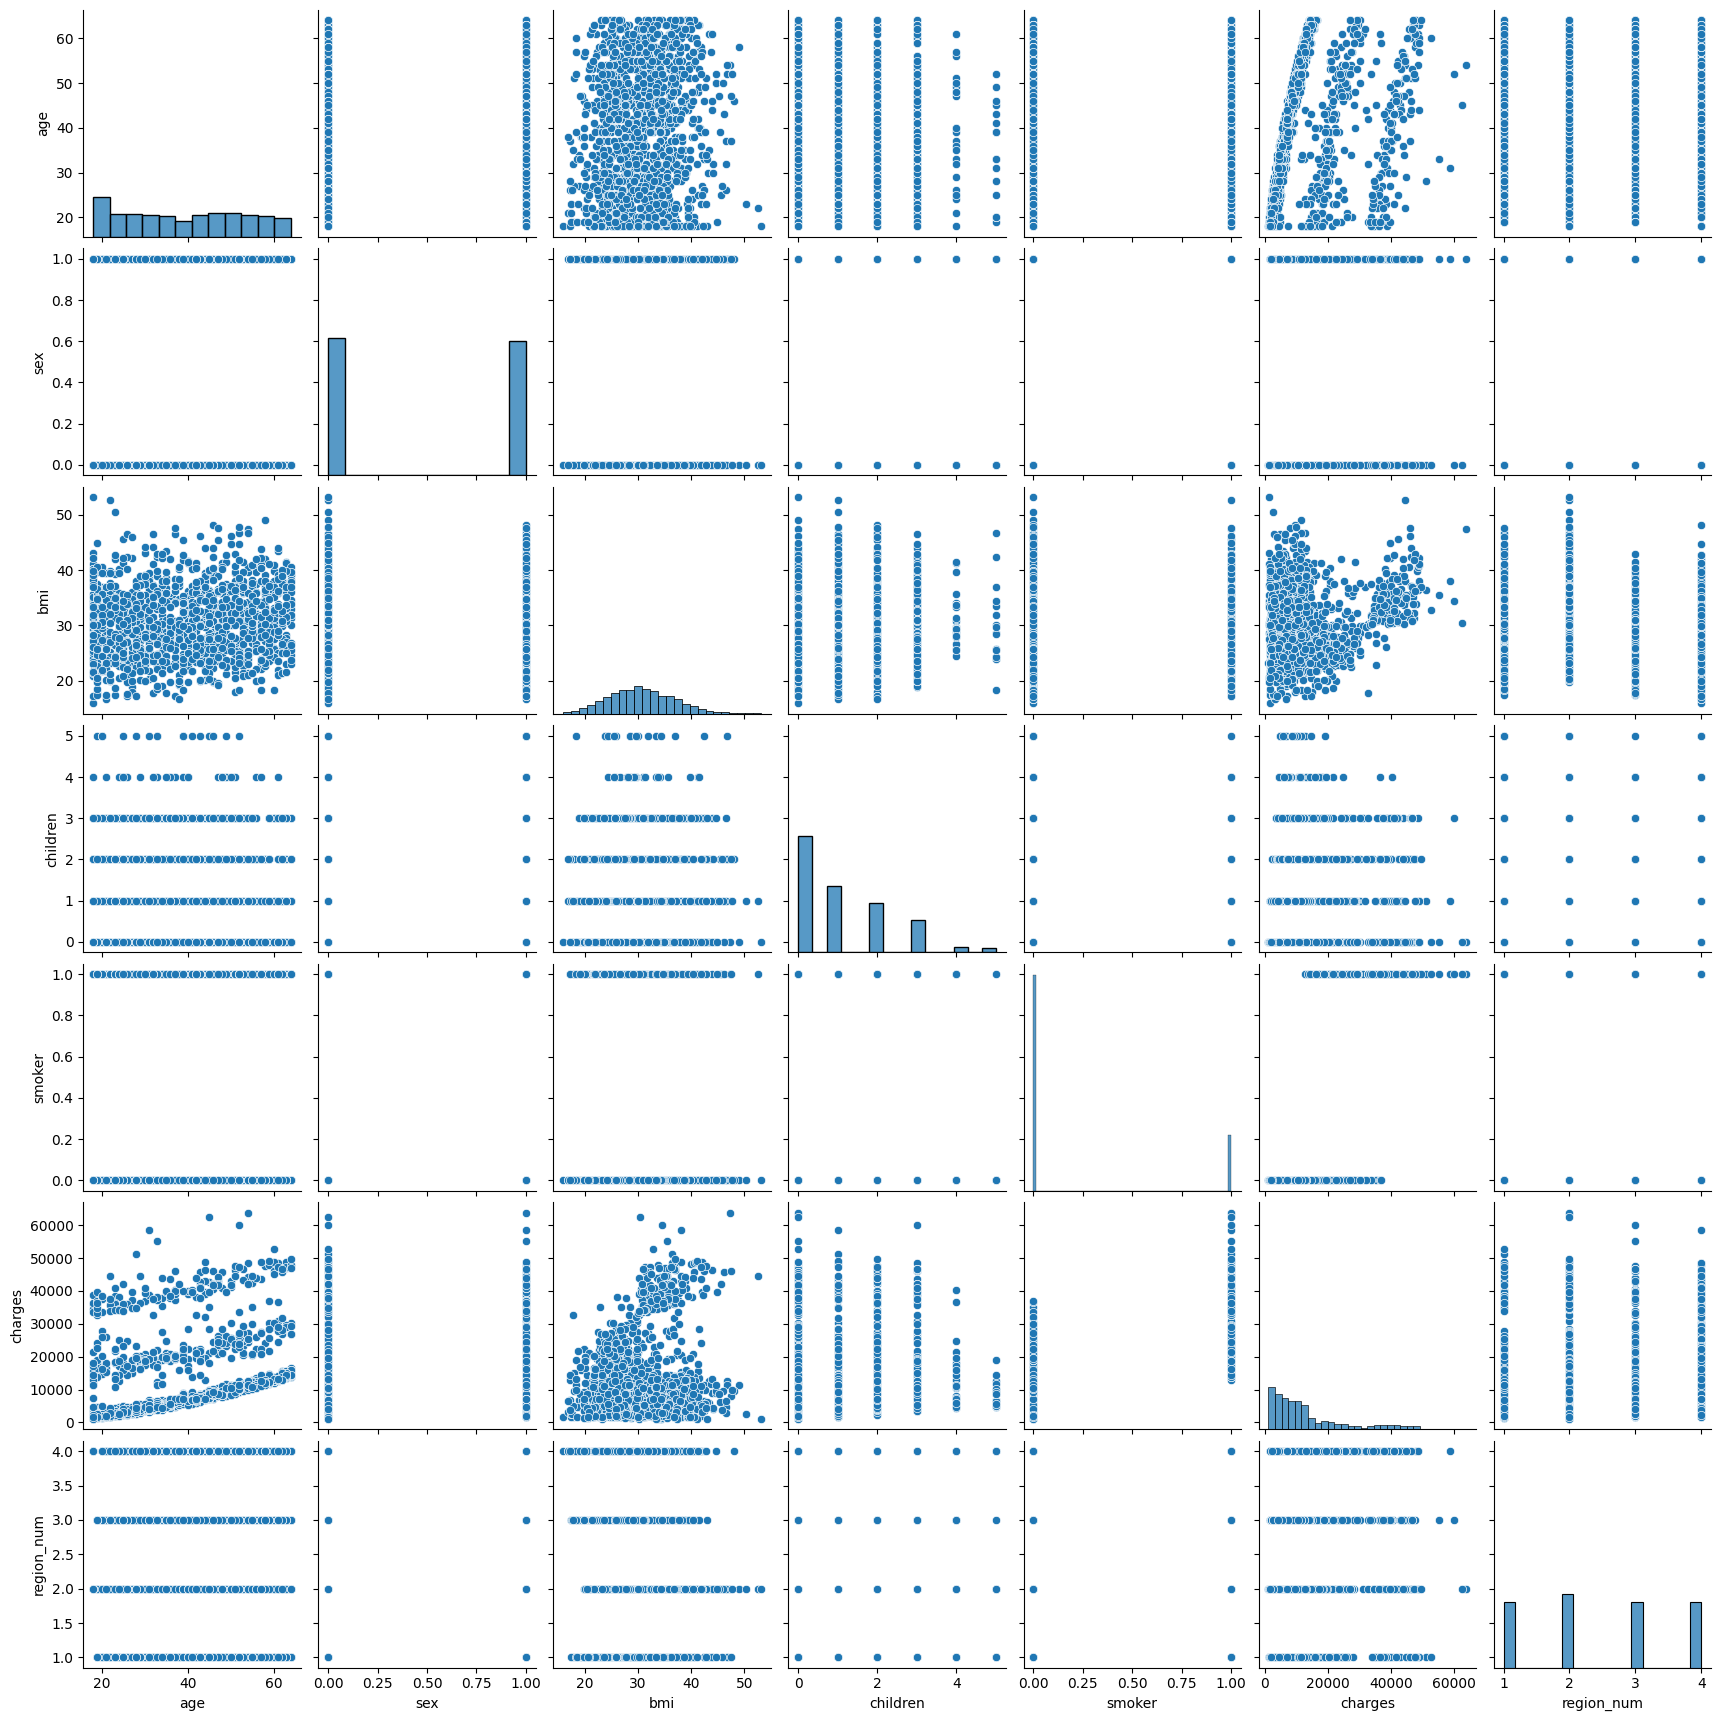

In [11]:
import seaborn as sns
sns.pairplot(df)

## Conclusion preliminar
Se identifica una separación de valores en la gráfica de cargos vs edad, dichas separaciones sugieren la existencia de una categoría oculta, para este caso la nombraremos economics y clasificara a los usuarios en un estrato económico ya que tambien se puede ver como la frecuencia de aparición disminuye conforme aumentan los cargos.

In [12]:
df.corr()

,age,sex,bmi,children,smoker,charges,region_num
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,-0.002127
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.004588
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.157566
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,-0.016569
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,0.002181
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,0.006208
region_num,-0.002127,0.004588,-0.157566,-0.016569,0.002181,0.006208,1.000000


In [13]:
from sklearn.cluster import KMeans
X_cluster = df[['age', 'charges']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['economics'] = kmeans.fit_predict(X_cluster)
print(df[['age', 'charges', 'economics']])

      age      charges  economics
0      19  16884.92400          1
1      18   1725.55230          0
2      28   4449.46200          0
3      33  21984.47061          1
4      32   3866.85520          0
...   ...          ...        ...
1333   50  10600.54830          0
1334   18   2205.98080          0
1335   18   1629.83350          0
1336   21   2007.94500          0
1337   61  29141.36030          2

[1338 rows x 3 columns]


In [14]:
X=df.drop('charges',axis=1)
Y=df['charges']

In [15]:

X.head()

,age,sex,bmi,children,smoker,region_num,economics
0,19,1,27.900,0,1,1,1
1,18,0,33.770,1,0,2,0
2,28,0,33.000,3,0,2,0
3,33,0,22.705,0,0,3,1
4,32,0,28.880,0,0,3,0


In [16]:
Y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

# se decide descartar feature de region ya que su correlacion es baja

In [18]:
X.drop(columns='region_num',inplace=True)

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

In [20]:
X_train.corr()

,age,sex,bmi,children,smoker,economics
age,1.000000,0.012385,0.111325,0.055070,-0.037916,0.252151
sex,0.012385,1.000000,-0.001931,-0.016610,-0.054671,-0.021598
bmi,0.111325,-0.001931,1.000000,-0.003459,-0.001499,0.146577
children,0.055070,-0.016610,-0.003459,1.000000,0.025488,0.021275
smoker,-0.037916,-0.054671,-0.001499,0.025488,1.000000,0.745672
economics,0.252151,-0.021598,0.146577,0.021275,0.745672,1.000000


In [21]:
X_train.shape,X_test.shape

((1003, 6), (335, 6))

In [22]:
#Estandarización

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Mean absolute error 2927.8997965893136
R2 Score 0.8941528301143259


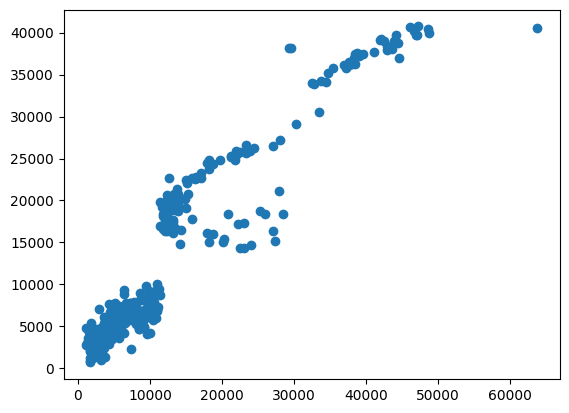

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 3598.923594604145
R2 Score 0.8470888605554158


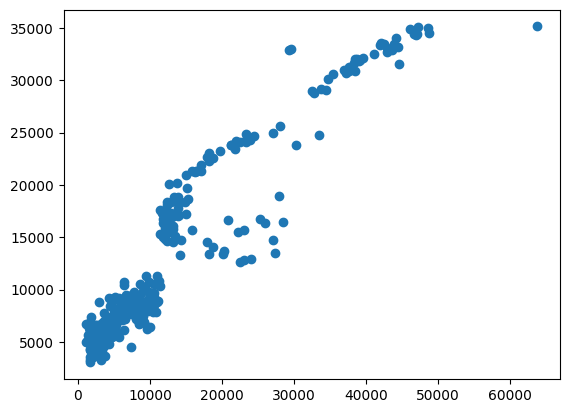

In [25]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
elastic=ElasticNet()
elastic.fit(X_train_scaled,y_train)
y_pred=elastic.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

Mean absolute error 2927.8451761397737
R2 Score 0.8941548309543248


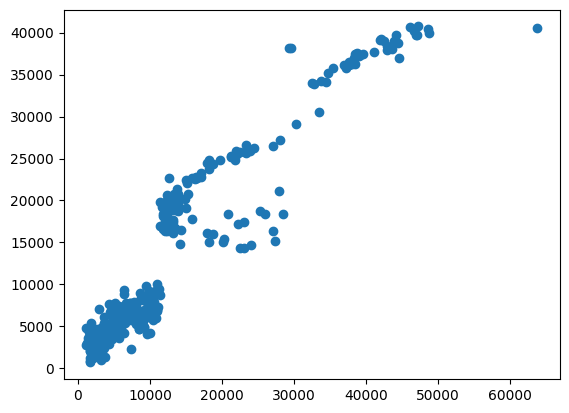

In [26]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
lasso=Lasso()
lasso.fit(X_train_scaled,y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age','sex','bmi','children','smoker']),
        ('cat', OneHotEncoder(drop='first'), ['economics'])
    ],
    remainder='passthrough'  
)

Mean absolute error 2168.4874691961713
R2 Score 0.9226555890858409


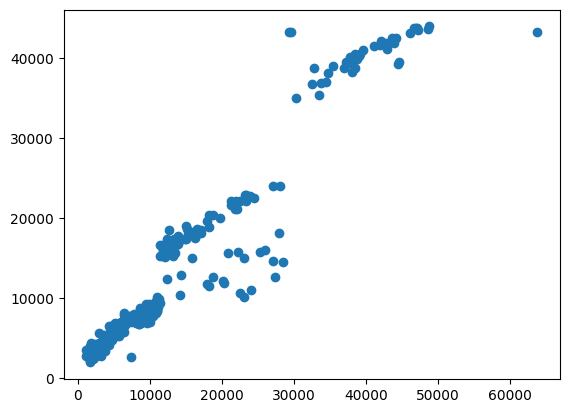

In [31]:
modelo = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regresion', Lasso())
])

modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)


In [35]:
nuevo = pd.DataFrame({'age': [24], 'sex': [1],'bmi':[30.000],'children':[2],'smoker':[0],'economics':[0]})
print(modelo.predict(nuevo))

[4604.74218912]


# Finalmente
Con el uso de regresion Lasso y aplicando OneHotEncoder al pipeline se obtienen las metricas de rendimiento mas altas, aunque el error absoluto promedio es alto debido a las mas altas categorias economicas, se acepta ya que no representa mas del 10% aproximadamente en relacion a la escala de cargos mas altos